<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amplitude, Energy & SH Reflection/Transmission — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 14 — Amplitude, Energy and Phase**

This notebook implements the three main quantitative threads from lecture:

1. **Energy flux and geometrical spreading** — confirming that amplitude falls off as $1/\sqrt{\text{area}}$ along a ray tube, and recovering the familiar $1/r$ spherical-spreading result as a special case.
2. **Geometrical spreading in a 1-D velocity model** — mapping the focal-sphere takeoff-angle band $d\theta$ onto the receiver-ring area $dX$ to get $\widetilde E(X)$, and showing where a caustic (a singularity in $dX/dp$) shows up as a spike.
3. **SH-wave reflection and transmission coefficients** — computing $R_{SH}(\theta_1)$ and $T_{SH}(\theta_1)$ from the elastic boundary conditions, and checking that energy flux is conserved across the interface at every angle.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (8, 6)

## Part 1 — Energy Flux Conservation Along a Ray Tube

A ray tube carries energy flux $\widetilde E^{flux} = \tfrac{1}{2} c \rho A^2 \omega^2$. Conservation of energy flux through the tube ($\widetilde E^{flux}(t_1)\,dS_1 = \widetilde E^{flux}(t_2)\,dS_2$) gives

$$\frac{A_2}{A_1} = \sqrt{\frac{dS_1}{dS_2}} \qquad \left(\text{and} \quad \frac{A_2}{A_1} = \sqrt{\frac{\rho_1 c_1}{\rho_2 c_2}} \ \text{ if } dS_1 = dS_2\right).$$

For a point source radiating into a uniform medium, the ray tube is a cone, so the cross-sectional area grows as $r^2$ and amplitude falls off as the familiar $1/r$.

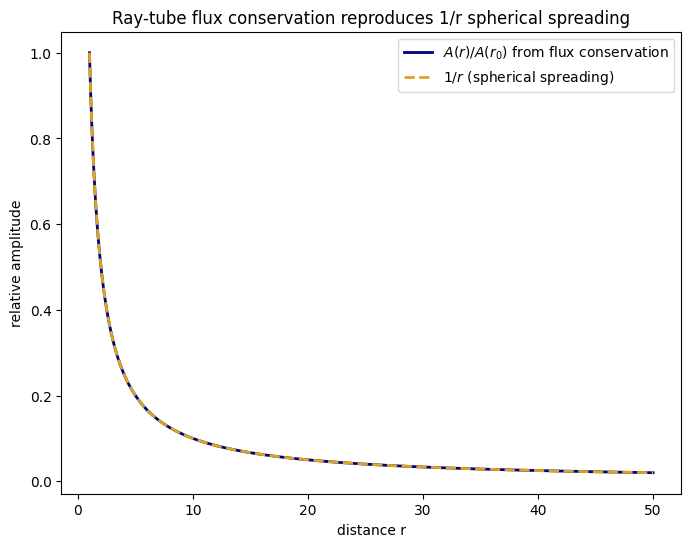

Max discrepancy between the two curves: 0.0


In [2]:
# Cross-sectional area of a ray tube (cone) at distance r from a point source
# grows as r^2, so A(r)/A(r0) = sqrt(dS(r0)/dS(r)) = r0 / r  --  spherical spreading.

r0 = 1.0
r = np.linspace(r0, 50, 500)

area_ratio = (r0 / r) ** 2          # dS(r0) / dS(r)
amp_ratio = np.sqrt(area_ratio)     # A(r) / A(r0)

plt.plot(r, amp_ratio, color="navy", lw=2, label=r"$A(r)/A(r_0)$ from flux conservation")
plt.plot(r, r0 / r, "--", color="goldenrod", lw=2, label=r"$1/r$ (spherical spreading)")
plt.xlabel("distance r")
plt.ylabel("relative amplitude")
plt.title("Ray-tube flux conservation reproduces 1/r spherical spreading")
plt.legend()
plt.show()

print("Max discrepancy between the two curves:", np.max(np.abs(amp_ratio - r0 / r)))

## Part 2 — Geometrical Spreading in a 1-D Velocity Model

For a 1-D velocity structure, energy leaving the source in a takeoff-angle band $d\theta_0$ around $\theta_0$ spreads over a receiver ring of width $dX$ at range $X$. Equating the energy in the two bands,

$$E_{d\theta} = \tfrac{1}{2}\sin\theta_0\, d\theta\, E_s, \qquad E_{dX} = 2\pi X \cos\theta_0\, dX\, \widetilde E(X),$$

gives

$$\widetilde E(X) = \frac{\sin\theta_0}{4\pi X \cos\theta_0}\left|\frac{d\theta}{dX}\right| E_s = \frac{p}{4\pi u_0^2 X \cos^2\theta_0}\left|\frac{dp}{dX}\right| E_s,$$

using the ray parameter $p = u_0 \sin\theta_0$. We build a simple constant-gradient velocity model, trace rays by their takeoff angle, and look at $X(p)$ and $\widetilde E(X)$ directly — including the caustic where $dX/dp \to 0$.

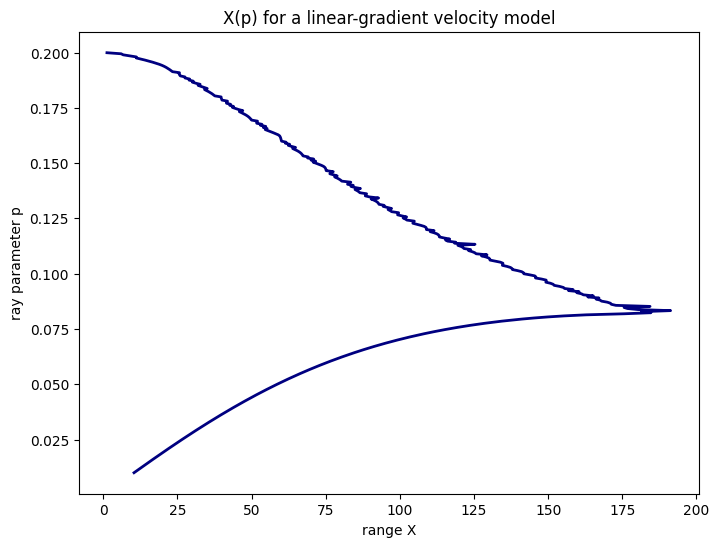

In [3]:
def trace_ray(p, v0, grad, zmax=60.0, n=4000):
    """Trace a ray with ray parameter p through a 1-D linear-gradient velocity
    model v(z) = v0 + grad*z, down to its turning point and back up to the surface.
    Returns the surface range X(p)."""
    z = np.linspace(0, zmax, n)
    v = v0 + grad * z
    u = 1.0 / v
    # turning depth: where u(z) == p
    sin2 = (p * v) ** 2
    valid = sin2 < 1.0
    if not np.any(valid):
        return np.nan
    z_turn = z[valid][-1]
    zz = np.linspace(0, z_turn, n)
    vv = v0 + grad * zz
    integrand = (p * vv) / np.sqrt(np.clip(1 - (p * vv) ** 2, 1e-12, None))
    trapz = getattr(np, "trapezoid", None) or np.trapz
    X = 2 * trapz(integrand, zz)
    return X

v0, grad = 5.0, 0.12
p_vals = np.linspace(0.01, 1 / v0 - 1e-4, 400)
X_vals = np.array([trace_ray(p, v0, grad) for p in p_vals])

plt.plot(X_vals, p_vals, color="navy", lw=2)
plt.xlabel("range X")
plt.ylabel("ray parameter p")
plt.title("X(p) for a linear-gradient velocity model")
plt.show()

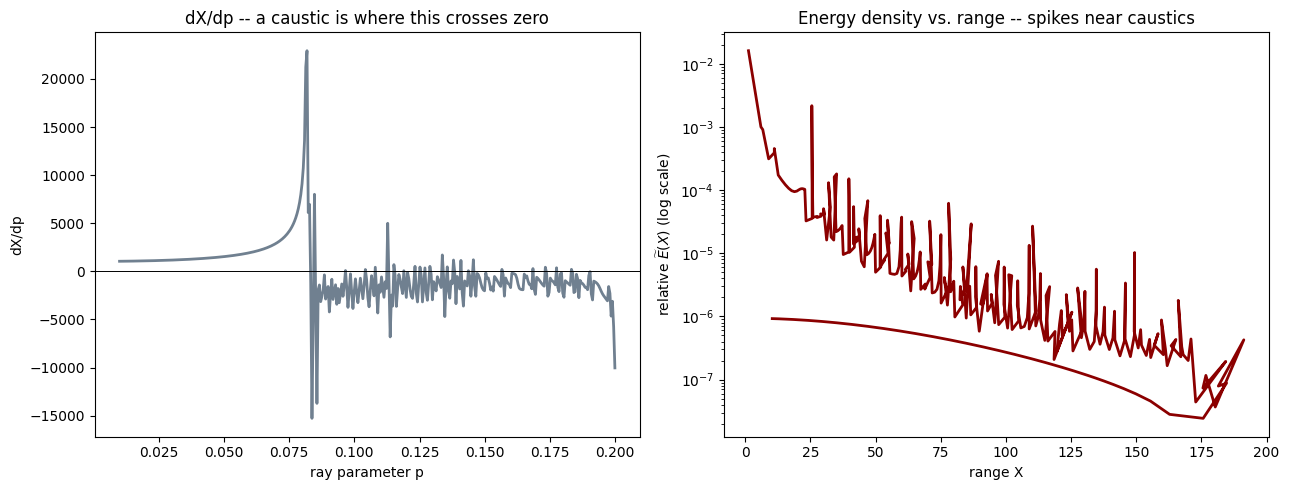

In [4]:
# dX/dp by finite differences, and E(X) up to the constant E_s factor:
#   E(X)  ~  (p / (X * cos^2(theta0))) * |dp/dX|   with  cos(theta0) = sqrt(1 - (p*v0)^2)

dXdp = np.gradient(X_vals, p_vals)
theta0 = np.arcsin(np.clip(p_vals * v0, -1, 1))
cos_theta0 = np.cos(theta0)

mask = (X_vals > 0.5) & np.isfinite(dXdp)
E_rel = np.abs(p_vals[mask] / (X_vals[mask] * cos_theta0[mask] ** 2) * (1.0 / dXdp[mask]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(p_vals, dXdp, color="slategray", lw=2)
axes[0].axhline(0, color="black", lw=0.7)
axes[0].set_xlabel("ray parameter p")
axes[0].set_ylabel("dX/dp")
axes[0].set_title("dX/dp -- a caustic is where this crosses zero")

axes[1].semilogy(X_vals[mask], E_rel, color="darkred", lw=2)
axes[1].set_xlabel("range X")
axes[1].set_ylabel(r"relative $\widetilde E(X)$ (log scale)")
axes[1].set_title("Energy density vs. range -- spikes near caustics")
plt.tight_layout()
plt.show()

Where `dX/dp` crosses zero, the predicted $\widetilde E(X)$ blows up — this is exactly the **caustic** singularity described in lecture: a range at which rays from a whole band of takeoff angles converge, focusing energy (and breaking the simple ray-theory amplitude prediction, which must be replaced by a diffraction treatment such as the Airy function near the caustic).

## Part 3 — SH-Wave Reflection and Transmission Coefficients

For an SH wave incident on a welded interface between two elastic half-spaces, continuity of displacement and traction gives

$$R_{SH} = \frac{A'}{A} = \frac{\rho_1\beta_1\cos\theta_1 - \rho_2\beta_2\cos\theta_2}{\rho_1\beta_1\cos\theta_1 + \rho_2\beta_2\cos\theta_2}, \qquad T_{SH} = \frac{A''}{A} = \frac{2\rho_1\beta_1\cos\theta_1}{\rho_1\beta_1\cos\theta_1 + \rho_2\beta_2\cos\theta_2},$$

with $\theta_2$ related to $\theta_1$ by Snell's law, $u_1\sin\theta_1 = u_2\sin\theta_2$ (i.e. $\sin\theta_1/\beta_1 = \sin\theta_2/\beta_2$).

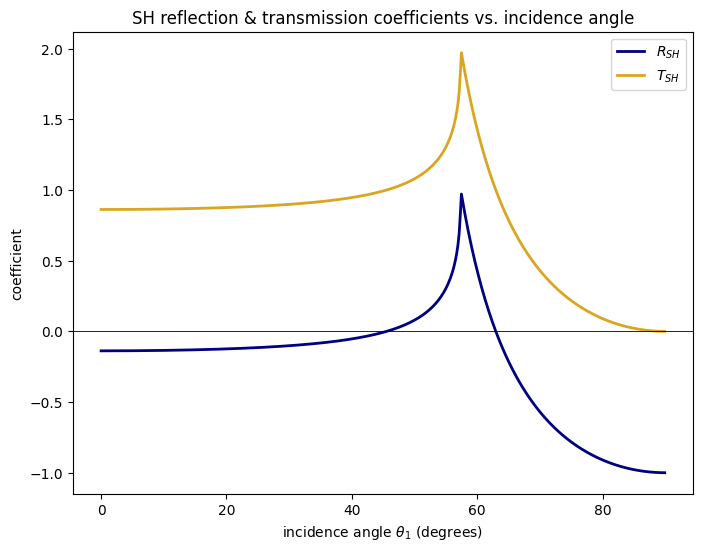

In [5]:
def R_T_SH(theta1_deg, rho1, beta1, rho2, beta2):
    """SH reflection/transmission coefficients as a function of incidence angle
    (in degrees), returning (R_SH, T_SH, theta2_deg). theta2 is np.nan past the
    critical angle (total internal reflection, beta2 > beta1 case)."""
    theta1 = np.radians(theta1_deg)
    p = np.sin(theta1) / beta1          # ray parameter (horizontal slowness)
    sin_theta2 = p * beta2
    with np.errstate(invalid="ignore"):
        cos_theta2 = np.sqrt(1 - sin_theta2 ** 2 + 0j)

    num_R = rho1 * beta1 * np.cos(theta1) - rho2 * beta2 * cos_theta2
    num_T = 2 * rho1 * beta1 * np.cos(theta1)
    den = rho1 * beta1 * np.cos(theta1) + rho2 * beta2 * cos_theta2

    R = num_R / den
    T = num_T / den
    theta2_deg = np.degrees(np.real(np.arcsin(np.clip(sin_theta2, -1, 1))))
    theta2_deg = np.where(np.abs(sin_theta2) <= 1, theta2_deg, np.nan)
    return np.real(R), np.real(T), theta2_deg

# Example: a crustal interface, velocity increasing with depth
rho1, beta1 = 2700.0, 3200.0   # kg/m^3, m/s  (layer 1)
rho2, beta2 = 3000.0, 3800.0   # kg/m^3, m/s  (layer 2, faster/denser)

theta1_deg = np.linspace(0, 89.9, 500)
R, T, theta2_deg = R_T_SH(theta1_deg, rho1, beta1, rho2, beta2)

plt.plot(theta1_deg, R, color="navy", lw=2, label=r"$R_{SH}$")
plt.plot(theta1_deg, T, color="goldenrod", lw=2, label=r"$T_{SH}$")
plt.axhline(0, color="black", lw=0.6)
plt.xlabel(r"incidence angle $\theta_1$ (degrees)")
plt.ylabel("coefficient")
plt.title("SH reflection & transmission coefficients vs. incidence angle")
plt.legend()
plt.show()

In [6]:
# Check the normal-incidence limit against the textbook special case:
R0, T0, _ = R_T_SH(np.array([0.0]), rho1, beta1, rho2, beta2)
Z1, Z2 = rho1 * beta1, rho2 * beta2
print(f"R_SH(0)  from formula      = {R0[0]: .4f}")
print(f"(Z1-Z2)/(Z1+Z2) (impedance) = {(Z1 - Z2) / (Z1 + Z2): .4f}")
print(f"T_SH(0)  from formula      = {T0[0]: .4f}")
print(f"2*Z1/(Z1+Z2)                = {2 * Z1 / (Z1 + Z2): .4f}")

R_SH(0)  from formula      = -0.1377
(Z1-Z2)/(Z1+Z2) (impedance) = -0.1377
T_SH(0)  from formula      =  0.8623
2*Z1/(Z1+Z2)                =  0.8623


### Energy flux conservation check

Energy flux carries a factor of $\rho c$ in addition to $A^2$, so the energy reflection and transmission coefficients are

$$\mathcal{R} = R_{SH}^2, \qquad \mathcal{T} = \frac{\rho_2\beta_2\cos\theta_2}{\rho_1\beta_1\cos\theta_1}\, T_{SH}^2,$$

and conservation of energy requires $\mathcal{R} + \mathcal{T} = 1$ at every angle (below the critical angle, where both waves actually propagate energy away from the interface).

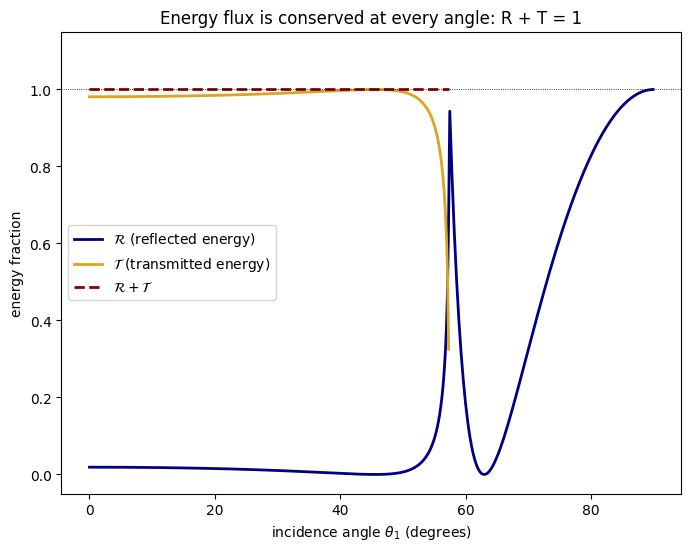

Max |R + T - 1| over all valid angles: 3.552713678800501e-15


In [7]:
def energy_RT_SH(theta1_deg, rho1, beta1, rho2, beta2):
    theta1 = np.radians(theta1_deg)
    R, T, theta2_deg = R_T_SH(theta1_deg, rho1, beta1, rho2, beta2)
    theta2 = np.radians(theta2_deg)
    energy_R = R ** 2
    energy_T = (rho2 * beta2 * np.cos(theta2)) / (rho1 * beta1 * np.cos(theta1)) * T ** 2
    return energy_R, energy_T

energy_R, energy_T = energy_RT_SH(theta1_deg, rho1, beta1, rho2, beta2)
total = energy_R + energy_T

plt.plot(theta1_deg, energy_R, color="navy", lw=2, label=r"$\mathcal{R}$ (reflected energy)")
plt.plot(theta1_deg, energy_T, color="goldenrod", lw=2, label=r"$\mathcal{T}$ (transmitted energy)")
plt.plot(theta1_deg, total, "--", color="darkred", lw=2, label=r"$\mathcal{R}+\mathcal{T}$")
plt.axhline(1.0, color="black", lw=0.6, ls=":")
plt.xlabel(r"incidence angle $\theta_1$ (degrees)")
plt.ylabel("energy fraction")
plt.title("Energy flux is conserved at every angle: R + T = 1")
plt.legend()
plt.ylim(-0.05, 1.15)
plt.show()

valid = ~np.isnan(total)
print("Max |R + T - 1| over all valid angles:", np.max(np.abs(total[valid] - 1.0)))

Because $\beta_2 > \beta_1$ here, there is **no critical angle** for the SH wave going from the slower into the faster medium in this direction — the transmitted wave stays real (propagating) at every incidence angle, and the energy check $\mathcal{R}+\mathcal{T}=1$ holds across the full $0$–$90^\circ$ range to numerical precision.

If instead $\beta_1 > \beta_2$ were swapped (try it by reversing which layer is "1"), a critical angle appears where $\sin\theta_2 = 1$; beyond it $T_{SH}$ becomes complex (an evanescent, non-propagating transmitted wave), $|R_{SH}| \to 1$, and all of the incident energy is reflected -- total internal reflection, just as in optics.

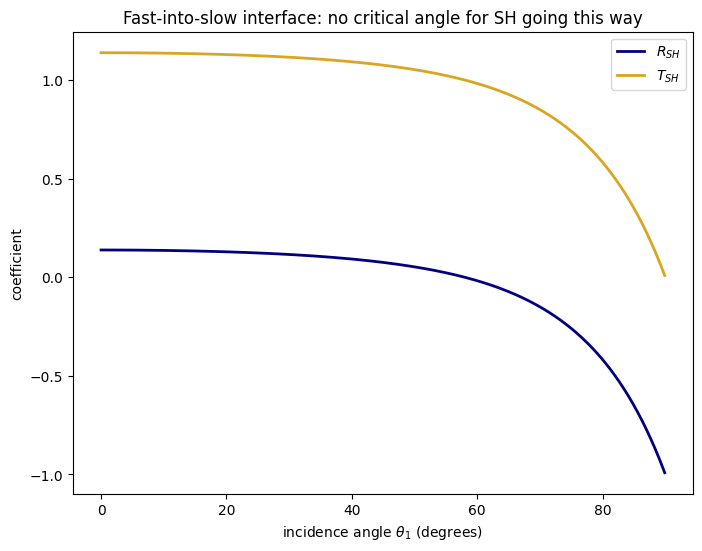

No critical angle in this direction (beta2 < beta1): total internal reflection does not occur.


In [8]:
# Swap roles: wave travels from the FASTER medium into the SLOWER one --> critical angle exists
rho1b, beta1b = 3000.0, 3800.0
rho2b, beta2b = 2700.0, 3200.0

theta_c = np.degrees(np.arcsin(beta1b / beta2b)) if beta2b > beta1b else None
Rb, Tb, theta2b_deg = R_T_SH(theta1_deg, rho1b, beta1b, rho2b, beta2b)

plt.plot(theta1_deg, Rb, color="navy", lw=2, label=r"$R_{SH}$")
plt.plot(theta1_deg, Tb, color="goldenrod", lw=2, label=r"$T_{SH}$")
if theta_c is not None:
    plt.axvline(theta_c, color="darkred", ls="--", lw=1.5,
                label=fr"critical angle $\theta_c={theta_c:.1f}^\circ$")
plt.xlabel(r"incidence angle $\theta_1$ (degrees)")
plt.ylabel("coefficient")
plt.title("Fast-into-slow interface: no critical angle for SH going this way")
plt.legend()
plt.show()
print("No critical angle in this direction (beta2 < beta1): total internal reflection does not occur.")

## Summary & Further Resources

- **Energy flux conservation** along a ray tube directly explains geometrical spreading: $A \propto 1/\sqrt{\text{area}}$, reducing to the familiar $1/r$ for spherical spreading from a point source.
- **Geometrical spreading in 1-D models** comes from mapping a takeoff-angle band onto a receiver-ring area; the Jacobian $dX/dp$ controls the amplitude, and a **caustic** ($dX/dp = 0$) produces a focusing singularity that ray theory alone cannot handle.
- **SH reflection/transmission coefficients** $R_{SH}$, $T_{SH}$ follow directly from displacement and traction continuity, reduce to the normal-incidence impedance-contrast formula at $\theta_1=0$, and satisfy energy flux conservation ($\mathcal R+\mathcal T=1$) at every propagating angle.
- **P-SV is next** — the same boundary-condition approach, but with four coupled waves (reflected/transmitted P and SV) instead of SH's clean two-wave system, as previewed at the end of lecture.